In [1]:
import os
os.environ["HF_HOME"] = "E:\\huggingface_cache"

from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
print("Loading dataset...")
dataset = load_dataset("huggan/wikiart", split="train")
print(f"Total images: {len(dataset)}")
print(f"Features: {dataset.features}")

Loading dataset...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

Total images: 81444
Features: {'image': Image(mode=None, decode=True), 'artist': ClassLabel(names=['Unknown Artist', 'boris-kustodiev', 'camille-pissarro', 'childe-hassam', 'claude-monet', 'edgar-degas', 'eugene-boudin', 'gustave-dore', 'ilya-repin', 'ivan-aivazovsky', 'ivan-shishkin', 'john-singer-sargent', 'marc-chagall', 'martiros-saryan', 'nicholas-roerich', 'pablo-picasso', 'paul-cezanne', 'pierre-auguste-renoir', 'pyotr-konchalovsky', 'raphael-kirchner', 'rembrandt', 'salvador-dali', 'vincent-van-gogh', 'hieronymus-bosch', 'leonardo-da-vinci', 'albrecht-durer', 'edouard-cortes', 'sam-francis', 'juan-gris', 'lucas-cranach-the-elder', 'paul-gauguin', 'konstantin-makovsky', 'egon-schiele', 'thomas-eakins', 'gustave-moreau', 'francisco-goya', 'edvard-munch', 'henri-matisse', 'fra-angelico', 'maxime-maufra', 'jan-matejko', 'mstislav-dobuzhinsky', 'alfred-sisley', 'mary-cassatt', 'gustave-loiseau', 'fernando-botero', 'zinaida-serebriakova', 'georges-seurat', 'isaac-levitan', 'joaquã\xa

In [ ]:
import matplotlib.pyplot as plt

# Get style and genre labels
style_names = dataset.features['style'].names
genre_names = dataset.features['genre'].names

# Count samples per style
style_counts = [0] * len(style_names)
genre_counts = [0] * len(genre_names)

for sample in dataset:
    style_counts[sample['style']] += 1
    genre_counts[sample['genre']] += 1

# Plot style distribution
plt.figure(figsize=(16, 6))
bars = plt.bar(style_names, style_counts, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Number of Images per Artistic Style')
plt.xlabel('Style')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('style_distribution.png', dpi=150)
plt.show()
print("Saved: style_distribution.png")

# Plot genre distribution
plt.figure(figsize=(10, 5))
plt.bar(genre_names, genre_counts, color='coral')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.title('Number of Images per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()
print("Saved: genre_distribution.png")

In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Display sample images from different styles
styles_to_show = [0, 3, 8, 12, 16, 20]  # Pick 6 different styles
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

print("Loading sample images...")
for i, style_idx in enumerate(tqdm(styles_to_show)):
    # Find first image of this style
    for sample in dataset:
        if sample['style'] == style_idx:
            axes[i].imshow(sample['image'])
            axes[i].set_title(style_names[style_idx], fontsize=9)
            axes[i].axis('off')
            break

plt.suptitle('Sample Images from Different Artistic Styles', fontsize=12)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
print("Saved: sample_images.png")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070
Loading dataset...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

Total images: 81444
Train: 57010 | Val: 12217 | Test: 12217
DataLoaders ready!
Model ready!


Epoch 1/5 [Val]: 100%|███████████████████████████████████████████████████████████████| 382/382 [04:54<00:00,  1.30it/s]


...

Epoch 3: Train Loss=0.8499, Train Acc=0.6854 | Val Loss=1.2960, Val Acc=0.5343


Epoch 4/5 [Val]: 100%|███████████████████████████████████████████████████████████████| 382/382 [05:14<00:00,  1.21it/s]


Epoch 4: Train Loss=0.7259, Train Acc=0.7358 | Val Loss=1.3292, Val Acc=0.5503


Epoch 5/5 [Val]: 100%|███████████████████████████████████████████████████████████████| 382/382 [05:10<00:00,  1.23it/s]


Epoch 5: Train Loss=0.6064, Train Acc=0.7854 | Val Loss=1.3660, Val Acc=0.5546
Model saved!


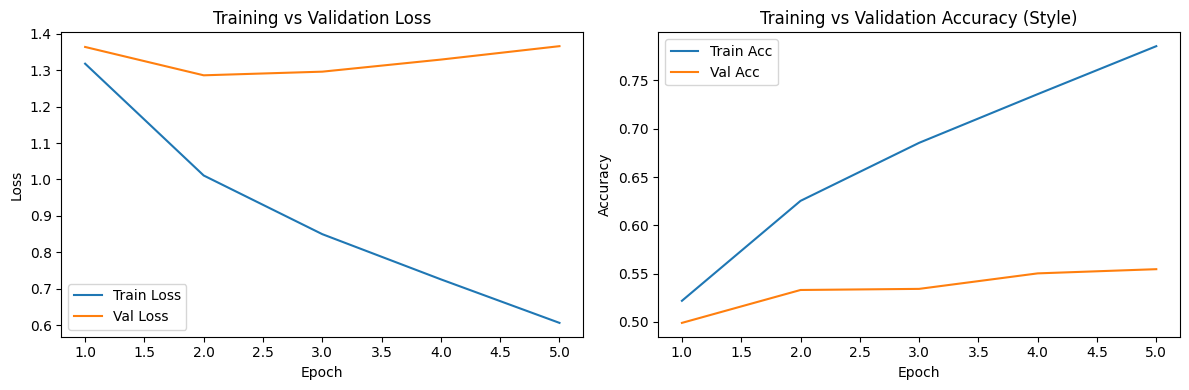

All done!


In [2]:
import os
os.environ["HF_HOME"] = "E:\\huggingface_cache"

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from datasets import load_dataset
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Device ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Load dataset ────────────────────────────────────────
print("Loading dataset...")
dataset = load_dataset("huggan/wikiart", split="train")
print(f"Total images: {len(dataset)}")

# ── Train/Val/Test split (70/15/15) ─────────────────────
total = len(dataset)
indices = list(range(total))
train_end = int(0.70 * total)
val_end   = int(0.85 * total)
train_indices = indices[:train_end]
val_indices   = indices[train_end:val_end]
test_indices  = indices[val_end:]
print(f"Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")

# ── Image transforms ────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── PyTorch Dataset ─────────────────────────────────────
class WikiArtDataset(Dataset):
    def __init__(self, hf_dataset, indices, transform):
        self.data      = hf_dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.data[self.indices[idx]]
        image  = sample['image'].convert('RGB')
        image  = self.transform(image)
        style  = sample['style']
        genre  = sample['genre']
        return image, style, genre

# ── DataLoaders (num_workers=0 for Windows) ─────────────
train_dataset = WikiArtDataset(dataset, train_indices, train_transform)
val_dataset   = WikiArtDataset(dataset, val_indices,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
print("DataLoaders ready!")

# ── Multi-task ResNet-50 ─────────────────────────────────
class MultiTaskResNet(nn.Module):
    def __init__(self, num_styles=27, num_genres=11):
        super().__init__()
        backbone = models.resnet50(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.style_head = nn.Linear(2048, num_styles)
        self.genre_head = nn.Linear(2048, num_genres)

    def forward(self, x):
        features = self.backbone(x)
        features = features.flatten(1)
        return self.style_head(features), self.genre_head(features)

model = MultiTaskResNet().to(device)
print("Model ready!")

# ── Loss & Optimizer ────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ── Training loop ───────────────────────────────────────
num_epochs = 5
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(num_epochs):
    # —— Train ——
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, styles, genres in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images  = images.to(device)
        styles  = styles.to(device)
        genres  = genres.to(device)

        optimizer.zero_grad()
        style_out, genre_out = model(images)
        loss = 0.7 * criterion(style_out, styles) + 0.3 * criterion(genre_out, genres)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct      += (style_out.argmax(1) == styles).sum().item()
        total        += styles.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # —— Validate ——
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, styles, genres in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images = images.to(device)
            styles = styles.to(device)
            genres = genres.to(device)

            style_out, genre_out = model(images)
            loss = 0.7 * criterion(style_out, styles) + 0.3 * criterion(genre_out, genres)
            val_loss    += loss.item()
            val_correct += (style_out.argmax(1) == styles).sum().item()
            val_total   += styles.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

# ── Save model ──────────────────────────────────────────
torch.save(model.state_dict(), "E:\\wikiart_project\\resnet50_wikiart.pth")
print("Model saved!")

# ── Plot training curves ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs+1), val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()

ax2.plot(range(1, num_epochs+1), train_accs, label='Train Acc')
ax2.plot(range(1, num_epochs+1), val_accs,   label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy (Style)')
ax2.legend()

plt.tight_layout()
plt.savefig('E:\\wikiart_project\\training_curves.png', dpi=150)
plt.show()
print("All done!")